In [3]:
import numpy as np
import matplotlib.pyplot as plt

Ice latitude:
m1 = 1.5000000000000018
b1 = -322.5000000000004

Planetary albedo:
m2 = -0.010000000000000016
b2 = 2.800000000000003


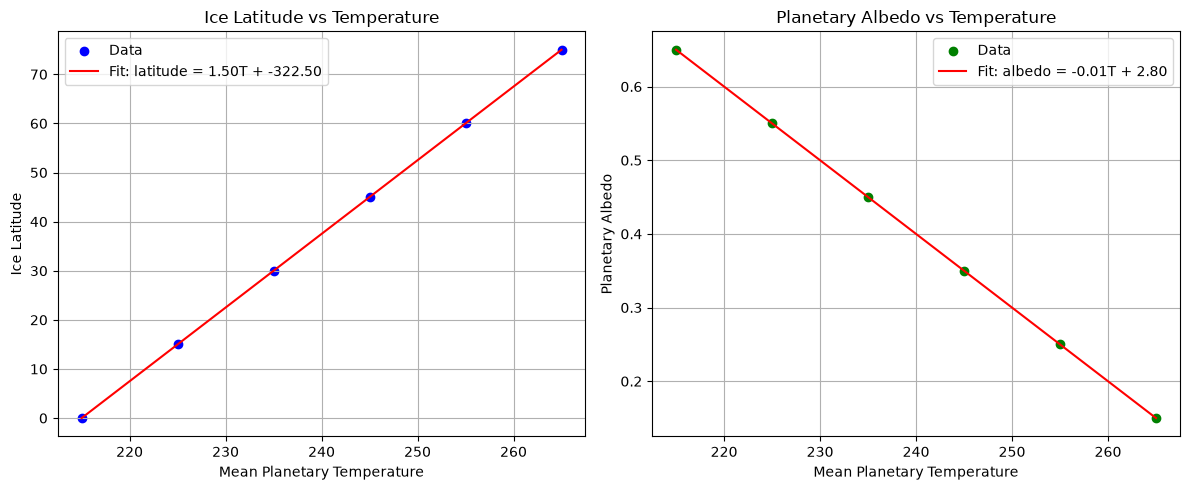

In [6]:
temps=np.array([265,255,245,235,225,215])
ice_latitude=np.array([75,60,45,30,15,0])
albedo=np.array([0.15,0.25,0.35,0.45,0.55,0.65])
A = np.column_stack((temps, np.ones_like(temps)))
m1, b1 = np.linalg.lstsq(A, ice_latitude, rcond=None)[0]
m2, b2 = np.linalg.lstsq(A, albedo, rcond=None)[0]


print("Ice latitude:")
print("m1 =", m1)
print("b1 =", b1)

print("\nPlanetary albedo:")
print("m2 =", m2)
print("b2 =", b2)

# Smooth temperature values for plotting the lines
T_line = np.linspace(temps.min(), temps.max(), 200)

ice_line = m1 * T_line + b1
albedo_line = m2 * T_line + b2

# Create two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ice latitude plot
axes[0].scatter(temps, ice_latitude, color="blue", label="Data")
axes[0].plot(
    T_line,
    ice_line,
    color="red",
    label=f"Fit: latitude = {m1:.2f}T + {b1:.2f}"
)
axes[0].set_xlabel("Mean Planetary Temperature")
axes[0].set_ylabel("Ice Latitude")
axes[0].set_title("Ice Latitude vs Temperature")
axes[0].legend()
axes[0].grid(True)

# Albedo plot
axes[1].scatter(temps, albedo, color="green", label="Data")
axes[1].plot(
    T_line,
    albedo_line,
    color="red",
    label=f"Fit: albedo = {m2:.2f}T + {b2:.2f}"
)
axes[1].set_xlabel("Mean Planetary Temperature")
axes[1].set_ylabel("Planetary Albedo")
axes[1].set_title("Planetary Albedo vs Temperature")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [7]:
LRange = [1200, 1600]
iterations = 100
epsilon = 1
sigma = 5.67E-8          # W/m2 K4

In [ ]:
L = LRange[1]
albedo = 0.15
while L > LRange[0] - 1:
    # Loop until albedo and temperature converge
    L = L - 10